# CRL Time Step Extension
CRL Team:

Luis Roberto Bustos Vargas (7084008)

Tirso Gustavo Ordaz Garcia (7082527)

## Team Contributions

The project was divided into two main components: the extension and evaluation of CITRIS, and the extension and evaluation of BISCUIT.

### Luis Roberto Bustos Vargas (Student ID: 70084008)

Luis was responsible for the CITRIS component of the project. His main contribution was the implementation of the **CITRIS Time Step Extension**, which extends the original CITRIS transition prior by incorporating information from multiple previous latent states through the configurable `history_length` parameter.

### Tirso Gustavo Ordaz Garcia (Student ID: 7082527)

Tirso was responsible for the BISCUIT component of the project. His main contribution was the implementation of the **BISCUIT Time Step Extension**, which extends the original BISCUIT paper by incorporating information from two previous latent states instead of one.


## Introduction

Causal Representation Learning (CRL) is a research area that aims to discover high-level causal variables and their relationships directly from low-level observations such as images or videos. Rather than learning latent representations that are only useful for prediction, CRL seeks representations that correspond to the true underlying factors governing the system.

Among recent CRL approaches, CITRIS and BISCUIT both aim to learn causal latent representations from temporal observations, but they differ in how they exploit intervention information. CITRIS assumes that intervention targets are available during training and uses them to guide causal representation learning, whereas BISCUIT relaxes this assumption by jointly inferring the intervention assignments while learning the latent representation. In this project, we implemented and evaluated extensions to both frameworks.


## Proposed Extension: Multiple Time Steps

Both CITRIS and BISCUIT are designed to learn causal representations from temporal data, where the underlying system evolves over time. In their original formulations, both models rely on a first-order temporal assumption, where the latent state at the next timestep is predicted primarily from the current latent state.

For CITRIS, this temporal dependency is modeled through the transition prior:

$$
p(z_{t+1}\mid z_t,I_{t+1})
$$

where the future latent state depends on the current latent state and the intervention target at the next timestep.

BISCUIT follows a similar temporal modeling assumption, but differs from CITRIS in how interventions are handled. While CITRIS assumes that intervention targets are available during training, BISCUIT aims to jointly infer intervention information together with the causal representation. Nevertheless, the temporal prediction remains based on the current latent state.

This formulation assumes that the current latent representation contains all relevant information required to predict future dynamics. However, some temporal properties cannot be inferred from a single observation. For example, the velocity or acceleration of an object cannot always be determined from its position at one timestep, but can be inferred from multiple consecutive observations.

To address this limitation, we propose a Time Step Extension, where models receive information from multiple previous latent states instead of relying only on the immediately preceding state.

## CITRIS
### Time Step Extension

Changes to the CITRIS implementation were performed by Luis Roberto Bustos Vargas (Student ID: 70084008). Unless explicitly indicated otherwise, all code originates from the original CITRIS implementation by Lippe et al. (2022).

We extend CITRIS by allowing the transition prior to incorporate information from a history of previous latent states. Instead of predicting the next state only from $z_t$, the extended model uses a temporal context:

$$
p(z_{t+1}\mid z_{t-k+1},...,z_t,I_{t+1})
$$

where $k$ is the ``history_length``, which denotes the number of latent states included in the temporal context window.

The main architectural modification is implemented in the transition prior. A new parameter `history_length` controls the number of previous latent states used as input.

For the original CITRIS setting:

$$
history\_length = 1
$$

the model receives only the previous latent state, making it equivalent to the original formulation.

For larger values, multiple latent states are concatenated and processed by the history encoder before being passed to the transition model. Other changes in the transition prior include renaming the ```z_t``` variable to ```history``` for better cohesion while reading the code.

```python
# CODE FROM models/shared/transition_prior.py
class TransitionPrior(nn.Module):
    def __init__(self, num_latents, num_blocks, c_hid,
                 imperfect_interventions=False,
                 autoregressive_model=False,
                 lambda_reg=0.01,
                 history_length=1, # ADDED PARAMETER
                 gumbel_temperature=1.0):
        
        #[ORIGINAL CODE]
        
        # Prior model creation
        if autoregressive_model:
            self.prior_model = AutoregressiveConditionalPrior(num_latents, num_blocks+1, 16, 2,
                                                              imperfect_interventions=self.imperfect_interventions)
        else:
            # Simple MLP per latent variable
            self.context_layer = nn.Linear(num_latents, c_hid*num_latents)
            self.history_length = history_length # ADDED  PARAMETER
            self.history_encoder = nn.Sequential( # ADDED HISTORY ENCODER
                nn.Linear(history_length * num_latents, num_latents),
                nn.SiLU()
            )
            self.inp_layer = MultivarLinear(1 + (self.num_blocks+1 if self.imperfect_interventions else 0), 
                                            c_hid, [self.num_latents])
            self.out_layer = nn.Sequential(
                    nn.SiLU(),
                    MultivarLinear(c_hid, c_hid, [self.num_latents]),
                    nn.SiLU(),
                    MultivarLinear(c_hid, 2, 
                                   [self.num_latents])
                )
            
    def _get_prior_params(self, history, target=None, target_prod=None, target_samples=None, z_t1=None):
        if self.autoregressive_model:
            prior_params = self.prior_model(z_samples=z_t1, 
                                            z_previous=history, 
                                            target_samples=target_samples,
                                            target_true=target)
            prior_params = prior_params.unbind(dim=-1)
        else:
            if history.shape[-1] != self.num_latents:# CHANGED z_t to history
                history = self.history_encoder(history)
            net_inp = history
            context = self.context_layer(net_inp).unflatten(-1, (self.num_latents, -1))
            #[ORIGINAL CODE]
        return prior_params
```

Importantly, the intervention mechanism and causal assignment components of CITRIS remain unchanged. The proposed extension only modifies the temporal information available to the transition prior.

As seen above, the added parameter also means we had to change the code where the transition prior is initialised:

```python
# CODE FROM models/citris_vae/lightning_module.py
self.prior_t1 = TransitionPrior(num_latents=self.hparams.num_latents,
    num_blocks=self.hparams.num_causal_vars,
    c_hid=self.hparams.c_hid,
    imperfect_interventions=self.hparams.imperfect_interventions,
    lambda_reg=self.hparams.lambda_reg,
    autoregressive_model=self.hparams.autoregressive_prior,
    history_length=self.hparams.history_length, # ADDED
    gumbel_temperature=self.hparams.classifier_gumbel_temperature)
```

Which takes us to the other main modification for this extension: the CITRIS-VAE training procedure was adapted to construct the temporal context required by the extended model. The encoder and decoder architectures remain unchanged. The modification only changes how latent representations are selected and passed to the transition prior.

```python
# CODE FROM models/citris_vae/lightning_module.py
def _get_loss(self, batch, mode='train'):
        # [ORIGINAL CODE]
        # Encode all frames. Decode only frames after the history window,
        # since the previous frames are used as transition context.
        z_mean, z_logstd = self.encoder(imgs.flatten(0, 1))
        z_sample = z_mean + torch.randn_like(z_mean) * z_logstd.exp()
        history_length = self.hparams.history_length

        z_sample_seq = z_sample.unflatten(0, imgs.shape[:2])

        x_rec = self.decoder(
            z_sample_seq[:, history_length:].flatten(0, 1)
        )
        z_sample, z_mean, z_logstd, x_rec = [t.unflatten(0, (imgs.shape[0], -1)) for t in [z_sample, z_mean, z_logstd, x_rec]]

        history = z_mean[:, :history_length].flatten(1)

        z_t1_mean = z_mean[:, history_length:]
        z_t1_logstd = z_logstd[:, history_length:]
        z_t1_sample = z_sample[:, history_length:]

        # Only the latest intervention
        target = target[:, history_length-1:]
```
The first history_length latent states are concatenated into a single history representation. Future latent states are used as prediction targets for the transition prior. The intervention targets are shifted to remain aligned with the corresponding latent transitions after increasing the history window.

```python
# CONTINUATION OF _get_loss in models/citris_vae/lightning_module.py
        if self.hparams.use_flow_prior:
            init_nll = -gaussian_log_prob(z_mean[:,history_length:], z_logstd[:,history_length:], z_sample[:,history_length:]).sum(dim=-1)
            z_sample, ldj = self.flow(z_sample.flatten(0, 1))
            z_sample = z_sample.unflatten(0, (imgs.shape[0], -1))
            z_t1_sample = z_sample[:, history_length:] # USES HISTORY_LENGTH
            ldj = ldj.unflatten(0, (imgs.shape[0], -1))[:,history_length:]
            out_nll = self.prior_t1.sample_based_nll(z_t1=z_t1_sample,
                                                        target=target.flatten(0,1),
                                                        z_t=history[:, None]
                                                    )
            # [ORIGINAL CODE]
        else:
            # Calculate KL divergence between every pair of frames
            kld_t1_all = self.prior_t1.kl_divergence(history=history, # USES HISTORY
                                                    target=target.flatten(0,1),
                                                    z_t1_mean=z_t1_mean.flatten(0,1),
                                                    z_t1_logstd=z_t1_logstd.flatten(0,1),
                                                    z_t1_sample=z_t1_sample.flatten(0,1)
                                                )
            kld_t1_all = kld_t1_all.unflatten(0, (imgs.shape[0], -1)).sum(dim=1)

        # Calculate reconstruction loss
        # rec_loss uses history_length
        if isinstance(self.decoder, nn.Identity):
            rec_loss = z_mean.new_zeros(imgs.shape[0], imgs.shape[1]-history_length)
        else:
            rec_loss = F.mse_loss(x_rec, labels[:,history_length:], reduction='none').sum(dim=[-3,-2,-1])
        # Combine to full loss
        kld_factor = self.kld_scheduler.get_factor(self.global_step)
        loss = (kld_factor * (kld_t1_all * self.hparams.beta_t1) + rec_loss.sum(dim=1)).mean()
        loss = loss / (imgs.shape[1] - history_length)
        # Add target classifier loss
        loss_model, loss_z = self.intv_classifier(z_sample=z_sample[:, history_length-1:],
                                                  logger=self if not self.hparams.cluster_logging else None, 
                                                  target=target,
                                                  transition_prior=self.prior_t1)
        loss = loss + (loss_model + loss_z) * self.hparams.beta_classifier
        # [ORIGINAL CODE]
        return loss
```
Frames used exclusively as temporal context are no longer reconstruction targets. Reconstruction loss is computed only for frames after the history window.

Overall, these changes modify only the temporal organization of the latent sequence. The encoder, decoder, intervention classifier, and causal variable assignment mechanisms remain unchanged. The extension therefore isolates the effect of providing additional temporal context to the transition prior.

#### CITRIS Implementation Summary

The proposed Time Step Extension required modifications across multiple components of the CITRIS implementation. The table below summarizes the purpose of each modified file.

| File | Purpose |
|------|---------|
| `models/shared/transition_prior.py` | Added the `history_length` parameter, introduced the history encoder, and extended the transition prior to process multiple latent states instead of a single previous latent state. |
| `models/citris_vae/lightning_module.py` | Modified the training pipeline to construct the latent history window, align prediction targets and intervention labels, and compute losses using the extended temporal context. |
| `experiments/train_vae.py` | Added the `--history_length` command-line argument, allowing the temporal context length to be configured without modifying the source code. |
| `models/shared/utils.py` | Added clamping of the latent log standard deviation before computing Gaussian log probabilities to improve numerical stability during training. |
| `experiments/utils.py` | Updated the training utilities for compatibility with newer versions of PyTorch Lightning and modern GPU execution. |
| `experiments/train_causal_encoder.py` | Enabled saving the final checkpoint (`last.ckpt`) to simplify experiment continuation and reproducibility. |

The first three modifications correspond to the proposed Time Step Extension and constitute the main contribution of this project. The remaining changes were introduced to improve reproducibility, numerical stability, and compatibility with the current software environment while preserving the original behavior of CITRIS.

### Experimental Setup


#### Dataset

Experiments were conducted using the **Interventional Pong** dataset provided with the original CITRIS implementation. The dataset consists of image sequences generated from a simulated environment in which several underlying causal variables evolve over time according to known intervention targets.

The causal variables in this dataset are:

- Ball velocity direction
- Ball x-position
- Ball y-position
- Left paddle y-position
- Right paddle y-position

---

#### Model Configuration

The proposed extension was evaluated using the original CITRIS-VAE architecture with the addition of the configurable `history_length` parameter.

Unless otherwise stated, all remaining hyperparameters were kept identical to those reported in the original implementation to ensure a fair comparison between the baseline model and the proposed extension.

| Parameter | Value |
|-----------|------:|
| Model | CITRIS-VAE |
| Epochs | 200 |
| Number of latent variables | 12 |
| Dataset | Interventional Pong |
| Graph learning method | ENCO |
| β_t1 | 10 |
| β_classifier | 10 |
| λ_sparse | 0.02 |
| History length | 1 (baseline), 2-4 (extension) |

---

#### Reproducibility

Since we are extending the original CITRIS implementation, running experiments has the same precondition of generating a dataset and training a causal encoder. Our extension was evaluated using CITRIS-VAE model. The experiments use the environment provided with the original CITRIS implementation, with minor compatibility adjustments to the library versions required for the current hardware and software environment. The exact package versions used for our experiments are provided in `citris-requirements.txt`.

Experiments can be reproduced using the following command:

```bash
python train_vae.py \
    --model CITRISVAE \
    --data_dir ../data_generation/interventional_pong/ \
    --causal_encoder_checkpoint ../data_generation/interventional_pong/models/last.ckpt \
    --num_latents 12 \
    --beta_t1 10 \
    --beta_classifier 10 \
    --graph_learning_method ENCO \
    --lambda_sparse 0.02 \
    --history_length 2
```

Setting

```text
--history_length 1
```

reproduces the original CITRIS implementation, while increasing the parameter enables the proposed Time Step Extension.

---

#### Evaluation Metrics

Following the original CITRIS evaluation protocol, we report three groups of metrics:

- **Triplet evaluation:** Evaluates whether the learned latent representation allows correct recombination of causal factors. The evaluation creates synthetic triplets by combining causal factors from two test samples and measuring the distance between the generated image's predicted causal factors and the ground-truth combination. Lower values indicate better disentanglement, with 0 representing perfect reconstruction of the causal factor combination.

- **R² (Coefficient of Determination):** Measures how accurately the learned latent representation predicts the ground-truth causal variables.

- **Spearman Rank Correlation:** Measures the monotonic relationship between the learned latent representation and the ground-truth causal variables.

For both the R² and Spearman metrics, we report two summary statistics:

- **Diagonal (diag):** The average correlation between each predicted causal factor and its corresponding ground-truth causal factor. Higher values are better, with an optimum of **1**.

- **Separated (sep):** The average of the highest correlation between each predicted causal factor and any *incorrect* causal factor. Lower values indicate better disentanglement, with an optimum of **0**.

### Results

The following results were generated using the evaluation script provided in the repository (results/results-citris):

```bash
python analyze_results.py
```

The following Table compares the original CITRIS temporal model with the proposed Time-Step Extension using different history lengths.

The baseline corresponds to `history_length=1`, where the model receives only the previous latent state, matching the original CITRIS formulation. Larger values incorporate additional previous latent states as temporal context.

Higher values are preferred for the R² and Spearman diagonal metrics, while lower values are preferred for separation metrics and triplet distances.

| Experiment | Triplet ↓ | R² diag ↑ | R² sep ↓ | Spearman diag ↑ | Spearman sep ↓ |
|------------|----------:|----------:|---------:|----------------:|---------------:|
| history_1  | 1.8614 | 0.8257 | 0.1829 | 0.8290 | 0.2146 |
| history_2  | 2.3476 | 0.8211 | 0.1825 | 0.8293 | 0.2489 |
| history_3  | 2.6491 | 0.8259 | 0.1752 | 0.8278 | 0.2157 |
| history_4  | 10.0620 | 0.7797 | 0.2816 | 0.7412 | 0.2623 |

**Reproducibility Note:** During the preparation of this notebook, the post-processing script used to summarize the separated (`sep`) metric was updated to match the definition provided in the original CITRIS paper. This change affects only the reporting of the evaluation metrics and does not require retraining the models or modify the learned representations.

The results show that incorporating additional temporal context produces similar disentanglement performance for moderate history lengths. The configurations with `history_length=2` and `history_length=3` achieve comparable R² and Spearman diagonal scores to the baseline, suggesting that the additional latent history does not negatively affect the ability of the model to identify causal factors.

However, increasing the history length further to `history_length=4` leads to a degradation across most metrics. In particular, both the correlation metrics and triplet distance deteriorate, indicating that providing a longer temporal context does not necessarily improve the learned representation and may introduce additional complexity into the transition model.

Overall, these results suggest that extending the transition prior with a limited temporal context is feasible, while excessively large history windows may make learning the temporal dynamics more challenging.

#### Latent-Causal Correlation Analysis

To further analyze the learned representations, we visualize the correlation between learned latent variables and the ground-truth causal factors.

Each row corresponds to one learned latent dimension, while each column corresponds to a causal factor from the dataset. A successful disentangled representation should produce a sparse correlation matrix, where each causal factor is primarily represented by one or a small subset of latent variables.

The heatmaps below show the R² correlation matrices for different values of `history_length`.

##### Baseline: history_length = 1

![history_1 correlation matrix](results/results-citris/history_1_r2_heatmap.png)

##### Extension: history_length = 2

![history_2 correlation matrix](results/results-citris/history_2_r2_heatmap.png)

##### Extension: history_length = 3

![history_3 correlation matrix](results/results-citris/history_3_r2_heatmap.png)

##### Extension: history_length = 4

![history_4 correlation matrix](results/results-citris/history_4_r2_heatmap.png)

The correlation matrices show that all configurations preserve a similar latent-to-causal alignment, indicating that the additional temporal context does not prevent the model from learning disentangled causal factors.

However, the `history_length=4` configuration exhibits weaker and more distributed correlations, which is consistent with the degradation observed in the quantitative metrics. This suggests that excessively large temporal windows may introduce unnecessary complexity into the transition model.

#### Training Dynamics

To analyze the effect of the temporal extension during optimization, we track the R² diagonal metric throughout training.

The R² diagonal measures how strongly each learned latent variable correlates with its corresponding causal factor, making it a useful indicator of disentanglement quality during training.

![r2_training_comparison](results/results-citris/r2_training_comparison.png)

The training curves show that the different history lengths follow similar optimization trajectories. Interestingly, `history_length=2` converged slightly faster than `history_length=1`, with a competitive R².

#### Conclusion

The experiments demonstrate that extending CITRIS with multiple temporal context steps is technically feasible and preserves the original causal representation learning capabilities for moderate history lengths.

The results indicate that additional temporal information alone does not guarantee improved disentanglement. While `history_length=2` and `history_length=3` achieve comparable performance to the baseline, increasing the temporal window further leads to worse results.

A possible explanation is that the transition prior must learn a more complex temporal dependency when more historical states are provided. Therefore, additional temporal information may only be beneficial when the selected history length matches the temporal dynamics of the underlying system.

## 🍪 BISCUIT: Causal Representation Learning from Temporal Sequences

Changes to the BISCUIT implementation were performed by Tirso Gustavo Ordaz Garcia (Student ID: 7082527). Unless explicitly indicated otherwise, all code originates from the original BISCUIT implementation by Lippe et al. (2023).

This section demonstrates our extension of the **BISCUIT** framework for causal representation learning. 

The original BISCUIT model successfully disentangles causal variables under a strict 1st-order Markov assumption (t-1 -> t). For our seminar presentation, we hypothesized that physical systems often require deeper historical context to model effectively. We extended the architecture to capture **2nd-order temporal sequences**, forcing the normalizing flow's transition prior to reason over a concatenated history (t-2, t-1 -> t).

Since the heavy model training and testing were executed on a computing cluster, this notebook serves as a lightweight, interactive guide to our methodology and final results. We will:

1. **Evaluate:** Load the pre-computed R-squared evaluation matrices for both the baseline and our custom 2nd-order model.
2. **Visualize:** Plot and compare the causal disentanglement heatmaps to prove that identifiability is maintained.
3. **Explain:** Walk through the exact architectural modifications required to adapt the temporal dimensions of the model.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import glob
import os

print("PyTorch Version:", torch.__version__)
print("Environment Ready!")

PyTorch Version: 2.4.1
Environment Ready!


In [7]:
# Path to baseline checkpoint matrix
baseline_path = 'results/baseline_r2_matrix.npz'

baseline_data = np.load(baseline_path)
baseline_matrix = baseline_data['values'][-1]  # Final epoch
baseline_r2 = np.diag(baseline_matrix).mean()

print(f"--- 1st-Order Baseline Model ---")
print(f"Path: {baseline_path}")
print(f"Average Diagonal R^2 Score: {baseline_r2:.4f}")

--- 1st-Order Baseline Model ---
Path: results/baseline_r2_matrix.npz
Average Diagonal R^2 Score: 0.9678


In [ ]:
# Path to 2nd-order checkpoint matrix
order2_path = 'results/2nd_order_r2_matrix.npz'


order2_data = np.load(order2_path)
order2_matrix = order2_data['values'][-1]  # Final epoch
order2_r2 = np.diag(order2_matrix).mean()

print(f"--- 2nd-Order Temporal Model (t-2, t-1 -> t) ---")
print(f"Path: {order2_path}")
print(f"Average Diagonal R^2 Score: {order2_r2:.4f}")

--- 2nd-Order Temporal Model (t-2, t-1 -> t) ---
Path: results/2nd_order_r2_matrix.npz
Average Diagonal R^2 Score: 0.9652


### Interpreting the Causal Disentanglement Heatmaps

Now that we have loaded the evaluation matrices for both models, we can visualize their performance side by side. 

These heatmaps display the **$R^2$ correlation** between the ground-truth causal factors of the CausalWorld dataset (y-axis) and the latent variables learned by our Normalizing Flows (x-axis). 

#### How to Read the Plots
The ultimate goal of causal representation learning is **disentanglement** meaning each individual learned latent variable should correspond to exactly *one* true underlying causal factor in the environment. 

*   **The Ideal Scenario:** A perfect model will produce a bright yellow diagonal line from the top left to the bottom right.
*   **Entanglement:** If a single row has multiple bright spots, it means the model entangled that single causal concept across multiple different latent variables.

#### What the Results Show
When you run the cell below, you will notice three key takeaways in the generated plot:

1.  **Perfect Alignment for Factors 0-5:** Both the baseline and our 2nd-order model exhibit a solid yellow diagonal for the first six causal factors. This means the models isolated these specific concepts into distinct latents.
2.  **Entanglement on Factor 6:** Looking at the bottom row. In both matrices, the correlation is spread out across learned latents 6 through 9.
3.  **The Core Idea:** Entanglement on the bottom row looks almost identical in both plots. By extending the model to accept a concatenated history ($x_{t-2}, x_{t-1} \to x_t$), we **did not introduce any new entanglement**. The 2nd-order model maintained the strict identifiability proofs of the original BISCUIT framework while successfully reasoning over a deeper temporal context.

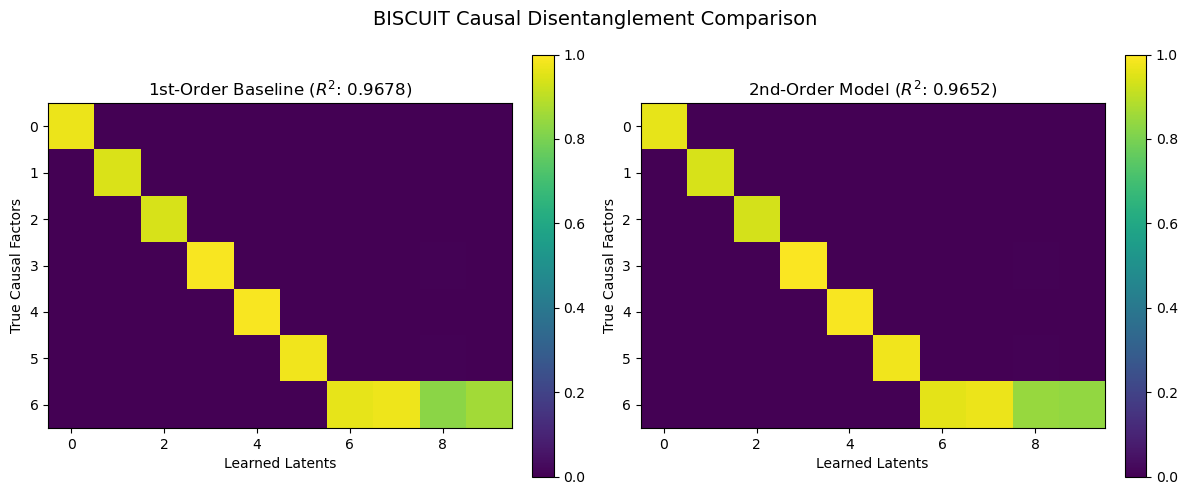

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Baseline
im0 = axes[0].imshow(baseline_matrix, vmin=0, vmax=1, cmap='viridis')
axes[0].set_title(f"1st-Order Baseline ($R^2$: {baseline_r2:.4f})")
axes[0].set_xlabel("Learned Latents")
axes[0].set_ylabel("True Causal Factors")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Plot 2nd-Order
im1 = axes[1].imshow(order2_matrix, vmin=0, vmax=1, cmap='viridis')
axes[1].set_title(f"2nd-Order Model ($R^2$: {order2_r2:.4f})")
axes[1].set_xlabel("Learned Latents")
axes[1].set_ylabel("True Causal Factors")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle("BISCUIT Causal Disentanglement Comparison", fontsize=14)
plt.tight_layout()
plt.show()

### Data Preparation & The Autoencoder

The experiments were run using the **CausalWorld** dataset, which consists of image sequences of a robotic hand interacting with blocks. 

However, training a Normalizing Flow directly on raw, high-dimensional pixel data is extremely computationally expensive. To solve this, BISCUIT uses a **two-stage architecture**:

1. **Stage 1 (Dimensionality Reduction):** A pre-trained Autoencoder compresses the raw images into a compact, 32-dimensional latent representation. 
2. **Stage 2 (Causal Discovery):** The Normalizing Flow (which we modify for 2nd-order dependencies) takes those 32 latents as input and learns to disentangle them into the true causal variables.

Before launching our experiments on the cluster, we first had to download the CausalWorld dataset and the pre-trained Autoencoder weights (`AE_32l_128hid.ckpt`).

Because the Autoencoder is fully pre-trained, we freeze its weights during our experiment. We simply pass the path of the `.ckpt` file into our training script using the `--autoencoder_checkpoint` argument. 

During training, the PyTorch Lightning module automatically loads this checkpoint, encodes the batches of raw images into the 32-dimensional latent space, and feeds that continuous sequence into our custom `BISCUITNF_2ndOrder` normalizing flow.

### The Theory: Moving Beyond the Markov Assumption

The standard BISCUIT architecture relies on a strict first-order **Markov assumption**. It assumes that the next state of the world ($z_t$) can be entirely predicted using only the immediate previous state ($z_{t-1}$) and the current action/intervention ($a_t$).

Mathematically, the baseline model learns this distribution:
$$ P(z_t | z_{t-1}, a_t) $$

However, in many real-world physical systems, a single previous frame doesn't capture the full dynamics (like velocity or acceleration). Our goal was to test if BISCUIT's causal identifiability proofs hold up if we force the model to learn **second-order temporal dependencies**, meaning the model must look at two historical time steps to predict the future:
$$ P(z_t | z_{t-1}, z_{t-2}, a_t) $$

By comparing the $R^2$ scores of the 1st-order and 2nd-order models, we can empirically verify if entangling the causal variables with a deeper history degrades the model's ability to disentangle the true causal factors.


### The Architectural Modifications

To implement this without modifying the original codebase, we created a new Python class (`BISCUITNF_2ndOrder`) that inherited from the baseline model. We had to modify three core components:

1. **The Data Pipeline:** Changed the dataloader to extract sequences of 3 frames (`--seq_len 3`) instead of the default 2.
2. **Latent Concatenation:** Sliced the model's latent representations into $z_{t-2}$, $z_{t-1}$, and $z_t$, and concatenated the historical states along the feature dimension to create a single doubled-context vector.
3. **Transition Prior:** The neural networks inside the transition prior were designed for 1st-order dimensions. We had to overwrite the `MultivarLinear` and `MultivarSequential` layers to accept exactly twice the number of input features (from 32 to 64).

# References

- Lippe et al. (2022). CITRIS.
- Official CITRIS implementation.
- Lippe et al. (2023). BISCUIT.
- Official BISCUIT implementation.